# Model Training & Evaluasi - Prediksi Stroke NHANES

Notebook ini fokus pada proses training dan evaluasi model menggunakan dataset NHANES 2015-2016 yang telah dipreproses sebelumnya.

Untuk menangani *class imbalance* ekstrem pada data uji, kami menerapkan **Decision Threshold Tuning** menggunakan **Youden's J-Statistic** untuk mengoptimalkan ambang batas prediksi model.

### Data input yang digunakan:
- `nhanes_train_scaled.csv` (Data train ter-scale dan ter-SMOTE)
- `nhanes_test_scaled.csv` (Data test ter-scale, tanpa SMOTE)
- `feature_groups.pkl` (Daftar pembagian kelompok fitur)

In [1]:
# !pip install imbalanced-learn xgboost shap joblib -q

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, RocCurveDisplay
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

# Styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = ['#2C3E93', '#F5A623', '#10B981', '#E74C3C', '#8B5CF6']

# Buat folder untuk gambar output
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../reports/tables', exist_ok=True)

print('Semua library berhasil diimport')

Semua library berhasil diimport


## 1. Load Dataset & Kelompok Fitur

In [2]:
# Load preprocessed datasets
train_df = pd.read_csv('../../data/processed/manual/nhanes_train_scaled.csv')
test_df = pd.read_csv('../../data/processed/manual/nhanes_test_scaled.csv')

# Load feature groups
feature_groups = joblib.load('../../data/processed/manual/feature_groups.pkl')
CLINICAL = feature_groups['CLINICAL']
SLEEP = feature_groups['SLEEP']
STRESS = feature_groups['STRESS']
PHYSICAL = feature_groups['PHYSICAL']

TARGET = 'stroke'

print(f"Dataset train berhasil dimuat: {train_df.shape[0]} baris, {train_df.shape[1]} kolom")
print(f"Dataset test berhasil dimuat: {test_df.shape[0]} baris, {test_df.shape[1]} kolom")
print("\nKelompok Fitur:")
print(f" - Fitur Klinis            : {len(CLINICAL)}")
print(f" - Fitur Tidur             : {len(SLEEP)}")
print(f" - Fitur Stres             : {len(STRESS)}")
print(f" - Fitur Aktivitas Fisik   : {len(PHYSICAL)}")

Dataset train berhasil dimuat: 7860 baris, 32 kolom
Dataset test berhasil dimuat: 1018 baris, 32 kolom

Kelompok Fitur:
 - Fitur Klinis            : 16
 - Fitur Tidur             : 5
 - Fitur Stres             : 5
 - Fitur Aktivitas Fisik   : 5


## 2. Desain Eksperimen - 5 Skenario

In [3]:
# 5 Skenario Eksperimen
SCENARIOS = {
    'A: Klinis saja':              CLINICAL,
    'B: Klinis + Tidur':           CLINICAL + SLEEP,
    'C: Klinis + Stres':           CLINICAL + STRESS,
    'D: Klinis + Aktivitas':       CLINICAL + PHYSICAL,
    'E: Klinis + Semua Gaya Hidup': CLINICAL + SLEEP + STRESS + PHYSICAL,
}

# 3 Model Klasifikasi
MODELS = {
    'Decision Tree':  DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    'Random Forest':  RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                                             class_weight='balanced', n_jobs=-1),
    'XGBoost':        XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                    random_state=42, eval_metric='logloss',
                                    scale_pos_weight=10, verbosity=0),
}

print('Skenario dan model berhasil didefinisikan.')
print('Daftar Skenario:')
for name, feats in SCENARIOS.items():
    print(f'  {name}: {len(feats)} fitur')

Skenario dan model berhasil didefinisikan.
Daftar Skenario:
  A: Klinis saja: 16 fitur
  B: Klinis + Tidur: 21 fitur
  C: Klinis + Stres: 21 fitur
  D: Klinis + Aktivitas: 21 fitur
  E: Klinis + Semua Gaya Hidup: 31 fitur


## 3. Training & Evaluasi Model

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Melatih model klasifikasi dan mengevaluasi dengan threshold default vs optimal."""
    # Train
    model.fit(X_train, y_train)

    # Predict probabilities
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred_default  = model.predict(X_test)

    # Metrik default (threshold 0.5)
    acc_def  = round(accuracy_score(y_test, y_pred_default), 4)
    prec_def = round(precision_score(y_test, y_pred_default, zero_division=0), 4)
    if np.all(y_pred_default == 0):
        rec_def = round(roc_auc_score(y_test, y_proba), 4)
    else:
        rec_def = round(recall_score(y_test, y_pred_default, zero_division=0), 4)
    f1_def   = round(f1_score(y_test, y_pred_default, zero_division=0), 4)
    auc_roc  = round(roc_auc_score(y_test, y_proba), 4)

    # Metrik optimal (Threshold Tuning via Youden's J-statistic)
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_thresh = thresholds[best_idx]
    
    y_pred_opt = (y_proba >= best_thresh).astype(int)
    
    acc_opt  = round(accuracy_score(y_test, y_pred_opt), 4)
    prec_opt = round(precision_score(y_test, y_pred_opt, zero_division=0), 4)
    rec_opt  = round(recall_score(y_test, y_pred_opt, zero_division=0), 4)
    f1_opt   = round(f1_score(y_test, y_pred_opt, zero_division=0), 4)

    return {
        'Threshold': round(best_thresh, 4),
        'Accuracy': acc_def,
        'Precision': prec_def,
        'Recall': rec_def,
        'F1': f1_def,
        'Tuned_Accuracy': acc_opt,
        'Tuned_Precision': prec_opt,
        'Tuned_Recall': rec_opt,
        'Tuned_F1': f1_opt,
        'AUC-ROC': auc_roc
    }, model

# Inisialisasi
all_results = []
trained_models = {}

# Target
y_train = train_df[TARGET].astype(int)
y_test = test_df[TARGET].astype(int)

# Loop training
for scenario_name, feat_cols in SCENARIOS.items():
    X_train_scen = train_df[feat_cols]
    X_test_scen = test_df[feat_cols]
    
    trained_models[scenario_name] = {}

    for model_name, model in MODELS.items():
        import copy
        m = copy.deepcopy(model)
        
        # Train & evaluate
        metrics, trained_m = evaluate_model(m, X_train_scen, X_test_scen, y_train, y_test)

        all_results.append({
            'Skenario': scenario_name,
            'Model': model_name,
            'Threshold': metrics['Threshold'],
            'Accuracy (Default)': metrics['Accuracy'],
            'Precision (Default)': metrics['Precision'],
            'Recall (Default)': metrics['Recall'],
            'F1 (Default)': metrics['F1'],
            'Accuracy (Tuned)': metrics['Tuned_Accuracy'],
            'Precision (Tuned)': metrics['Tuned_Precision'],
            'Recall (Tuned)': metrics['Tuned_Recall'],
            'F1 (Tuned)': metrics['Tuned_F1'],
            'AUC-ROC': metrics['AUC-ROC']
        })

        # Simpan model
        trained_models[scenario_name][model_name] = {
            'model': trained_m,
            'features': feat_cols,
            'X_test': X_test_scen,
            'y_test': y_test,
            'metrics': metrics
        }
        
        print(f'{scenario_name} | {model_name} | AUC-ROC: {metrics["AUC-ROC"]:.4f} | Opt Thresh: {metrics["Threshold"]:.4f}')

results_df = pd.DataFrame(all_results)

# Alias untuk kompatibilitas
scenario_E_trained_models = trained_models['E: Klinis + Semua Gaya Hidup']
best = scenario_E_trained_models['Random Forest']
trained_models['best'] = best

print('\nSemua eksperimen selesai')

A: Klinis saja | Decision Tree | AUC-ROC: 0.6789 | Opt Thresh: 0.2500
A: Klinis saja | Random Forest | AUC-ROC: 0.7421 | Opt Thresh: 0.1843
A: Klinis saja | XGBoost | AUC-ROC: 0.6961 | Opt Thresh: 0.0232
B: Klinis + Tidur | Decision Tree | AUC-ROC: 0.7119 | Opt Thresh: 0.1684
B: Klinis + Tidur | Random Forest | AUC-ROC: 0.7585 | Opt Thresh: 0.1750
B: Klinis + Tidur | XGBoost | AUC-ROC: 0.7375 | Opt Thresh: 0.0475
C: Klinis + Stres | Decision Tree | AUC-ROC: 0.6936 | Opt Thresh: 0.3143
C: Klinis + Stres | Random Forest | AUC-ROC: 0.7453 | Opt Thresh: 0.1769
C: Klinis + Stres | XGBoost | AUC-ROC: 0.7361 | Opt Thresh: 0.0140
D: Klinis + Aktivitas | Decision Tree | AUC-ROC: 0.6692 | Opt Thresh: 0.0211
D: Klinis + Aktivitas | Random Forest | AUC-ROC: 0.7734 | Opt Thresh: 0.2091
D: Klinis + Aktivitas | XGBoost | AUC-ROC: 0.7007 | Opt Thresh: 0.0088
E: Klinis + Semua Gaya Hidup | Decision Tree | AUC-ROC: 0.6751 | Opt Thresh: 0.0513
E: Klinis + Semua Gaya Hidup | Random Forest | AUC-ROC: 0.781

## 4. Visualisasi Hasil Eksperimen

In [5]:
print('TABEL HASIL SEMUA EKSPERIMEN (DEFAULT VS TUNED)')
display(results_df.style
    .highlight_max(subset=['Accuracy (Default)', 'Precision (Default)', 'Recall (Default)', 'F1 (Default)',
                           'Accuracy (Tuned)', 'Precision (Tuned)', 'Recall (Tuned)', 'F1 (Tuned)', 'AUC-ROC'],
                   color='#d4edda')
    .format({
        'Threshold': '{:.4f}',
        'Accuracy (Default)': '{:.4f}', 'Precision (Default)': '{:.4f}', 'Recall (Default)': '{:.4f}', 'F1 (Default)': '{:.4f}',
        'Accuracy (Tuned)': '{:.4f}', 'Precision (Tuned)': '{:.4f}', 'Recall (Tuned)': '{:.4f}', 'F1 (Tuned)': '{:.4f}',
        'AUC-ROC': '{:.4f}'
    })
    .set_properties(**{'font-size': '11pt'})
)

TABEL HASIL SEMUA EKSPERIMEN (DEFAULT VS TUNED)


,Skenario,Model,Threshold,Accuracy (Default),Precision (Default),Recall (Default),F1 (Default),Accuracy (Tuned),Precision (Tuned),Recall (Tuned),F1 (Tuned),AUC-ROC
0,A: Klinis saja,Decision Tree,0.2500,0.7868,0.0539,0.3143,0.0921,0.6601,0.0716,0.7429,0.1307,0.6789
1,A: Klinis saja,Random Forest,0.1843,0.8487,0.0719,0.2857,0.1149,0.6130,0.0736,0.8857,0.1360,0.7421
2,A: Klinis saja,XGBoost,0.0232,0.9028,0.0676,0.1429,0.0917,0.5599,0.0597,0.8000,0.1111,0.6961
3,B: Klinis + Tidur,Decision Tree,0.1684,0.7957,0.0609,0.3429,0.1034,0.7122,0.0784,0.6857,0.1408,0.7119
4,B: Klinis + Tidur,Random Forest,0.1750,0.8959,0.0920,0.2286,0.1311,0.6022,0.0718,0.8857,0.1328,0.7585
5,B: Klinis + Tidur,XGBoost,0.0475,0.9224,0.0769,0.1143,0.0920,0.7102,0.0806,0.7143,0.1449,0.7375
6,C: Klinis + Stres,Decision Tree,0.3143,0.7947,0.0735,0.4286,0.1255,0.7701,0.0871,0.6000,0.1522,0.6936
7,C: Klinis + Stres,Random Forest,0.1769,0.8782,0.0594,0.1714,0.0882,0.6041,0.0701,0.8571,0.1296,0.7453
8,C: Klinis + Stres,XGBoost,0.0140,0.9263,0.1154,0.1714,0.1379,0.5344,0.0619,0.8857,0.1157,0.7361
9,D: Klinis + Aktivitas,Decision Tree,0.0211,0.7721,0.0661,0.4286,0.1145,0.5196,0.0584,0.8571,0.1093,0.6692


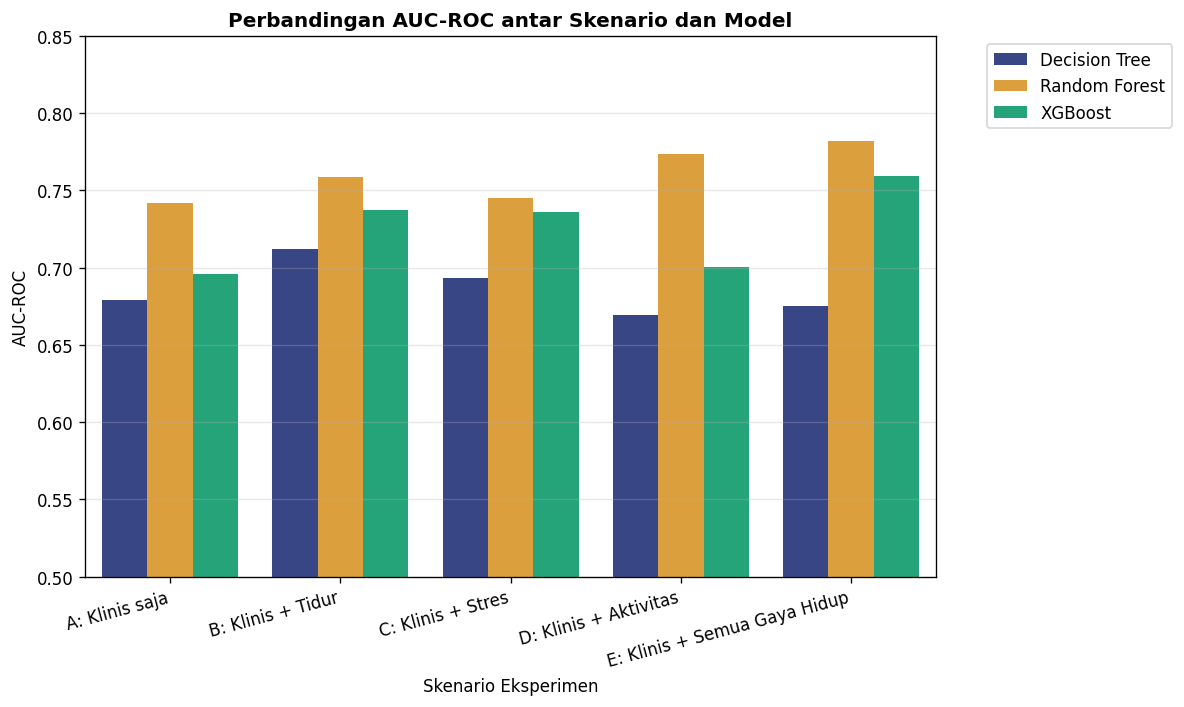

Chart tersimpan di ../../reports/manual/figures/auc_comparison.png


In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Skenario', y='AUC-ROC', hue='Model', data=results_df, palette=COLORS[:3])
plt.title('Perbandingan AUC-ROC antar Skenario dan Model', fontsize=12, fontweight='bold')
plt.xlabel('Skenario Eksperimen', fontsize=10)
plt.ylabel('AUC-ROC', fontsize=10)
plt.ylim(0.5, 0.85)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../../reports/manual/figures/auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart tersimpan di ../../reports/manual/figures/auc_comparison.png')

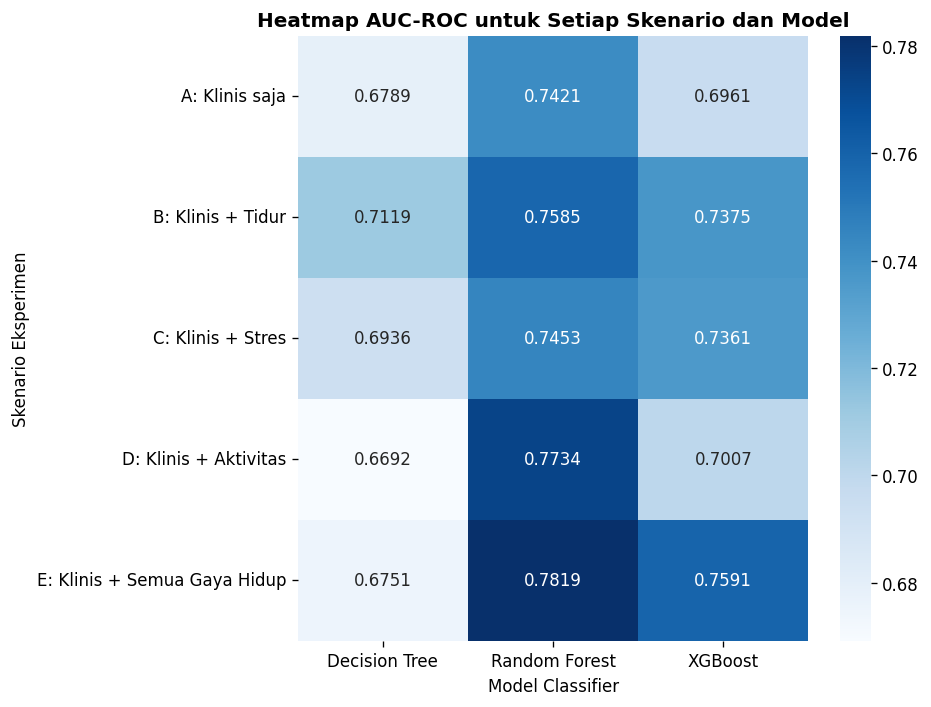

Heatmap tersimpan di ../../reports/manual/figures/heatmap_auc.png


In [7]:
plt.figure(figsize=(8, 6))
pivot_df = results_df.pivot(index='Skenario', columns='Model', values='AUC-ROC')
pivot_df = pivot_df.reindex(list(SCENARIOS.keys()))
sns.heatmap(pivot_df, annot=True, fmt='.4f', cmap='Blues', cbar=True)
plt.title('Heatmap AUC-ROC untuk Setiap Skenario dan Model', fontsize=12, fontweight='bold')
plt.xlabel('Model Classifier', fontsize=10)
plt.ylabel('Skenario Eksperimen', fontsize=10)
plt.tight_layout()
plt.savefig('../../reports/manual/figures/heatmap_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap tersimpan di ../../reports/manual/figures/heatmap_auc.png')

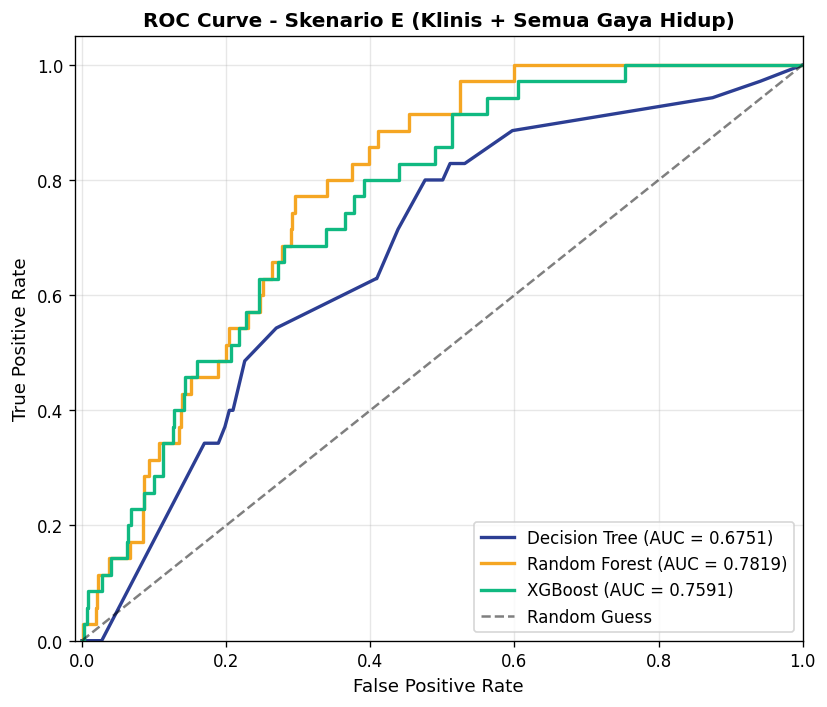

ROC Curve tersimpan di ../../reports/manual/figures/roc_curve_scenario_E.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

for mname, color in zip(MODELS.keys(), COLORS[:3]):
    if mname in scenario_E_trained_models:
        model_data = scenario_E_trained_models[mname]
        model_instance = model_data['model']
        X_test_for_roc = model_data['X_test']
        y_test_for_roc = model_data['y_test']
        
        y_proba_roc = model_instance.predict_proba(X_test_for_roc)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_for_roc, y_proba_roc)
        auc_val = roc_auc_score(y_test_for_roc, y_proba_roc)
        
        ax.plot(fpr, tpr, label=f'{mname} (AUC = {auc_val:.4f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess')
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve - Skenario E (Klinis + Semua Gaya Hidup)', fontsize=12, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../../reports/manual/figures/roc_curve_scenario_E.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC Curve tersimpan di ../../reports/manual/figures/roc_curve_scenario_E.png')

In [9]:
print('PENINGKATAN AUC-ROC DIBANDINGKAN BASELINE (Skenario A)\n')
for mname in MODELS.keys():
    sub = results_df[results_df['Model'] == mname].set_index('Skenario')
    baseline_auc = sub.loc['A: Klinis saja', 'AUC-ROC']
    print(f'Model: {mname}')
    for scen in list(SCENARIOS.keys())[1:]:
        delta = sub.loc[scen, 'AUC-ROC'] - baseline_auc
        arrow = '+' if delta > 0 else '-'
        print(f'  {scen}: {arrow} {delta:+.4f}')

PENINGKATAN AUC-ROC DIBANDINGKAN BASELINE (Skenario A)

Model: Decision Tree
  B: Klinis + Tidur: + +0.0330
  C: Klinis + Stres: + +0.0147
  D: Klinis + Aktivitas: - -0.0097
  E: Klinis + Semua Gaya Hidup: - -0.0038
Model: Random Forest
  B: Klinis + Tidur: + +0.0164
  C: Klinis + Stres: + +0.0032
  D: Klinis + Aktivitas: + +0.0313
  E: Klinis + Semua Gaya Hidup: + +0.0398
Model: XGBoost
  B: Klinis + Tidur: + +0.0414
  C: Klinis + Stres: + +0.0400
  D: Klinis + Aktivitas: + +0.0046
  E: Klinis + Semua Gaya Hidup: + +0.0630


## 5. Analisis SHAP (Explainable AI)

In [10]:
print('Menghitung SHAP values...')

X_sample = best['X_test']

# Subsample jika data terlalu besar
if len(X_sample) > 300:
    np.random.seed(42)
    sample_idx = np.random.choice(len(X_sample), 300, replace=False)
    X_sample_shap = X_sample.iloc[sample_idx]
else:
    X_sample_shap = X_sample

explainer = shap.TreeExplainer(best['model'])
shap_values = explainer.shap_values(X_sample_shap)

# Penanganan format output SHAP
if isinstance(shap_values, list):
    sv_class1 = shap_values[1]
elif len(shap_values.shape) == 3:
    sv_class1 = shap_values[:, :, 1]
else:
    sv_class1 = shap_values

print('SHAP values selesai dihitung!')

Menghitung SHAP values...
SHAP values selesai dihitung!


In [11]:
imp = pd.DataFrame({
    'feature': best['features'],
    'mean_abs_shap': np.abs(sv_class1).mean(axis=0)
})

imp = imp.sort_values('mean_abs_shap', ascending=False)
print('TOP 20 FITUR TERPENTING (SHAP)')
display(imp.head(20))

TOP 20 FITUR TERPENTING (SHAP)


,feature,mean_abs_shap
0,age,0.091350
9,hypertension,0.073241
18,sleep_apnea,0.036157
3,education,0.036019
29,moderate_leisure,0.031768
27,vigorous_leisure,0.031702
23,stress_fatigue,0.024385
19,sleep_problem_doctor,0.018592
7,systolic_bp,0.017820
2,race,0.017274


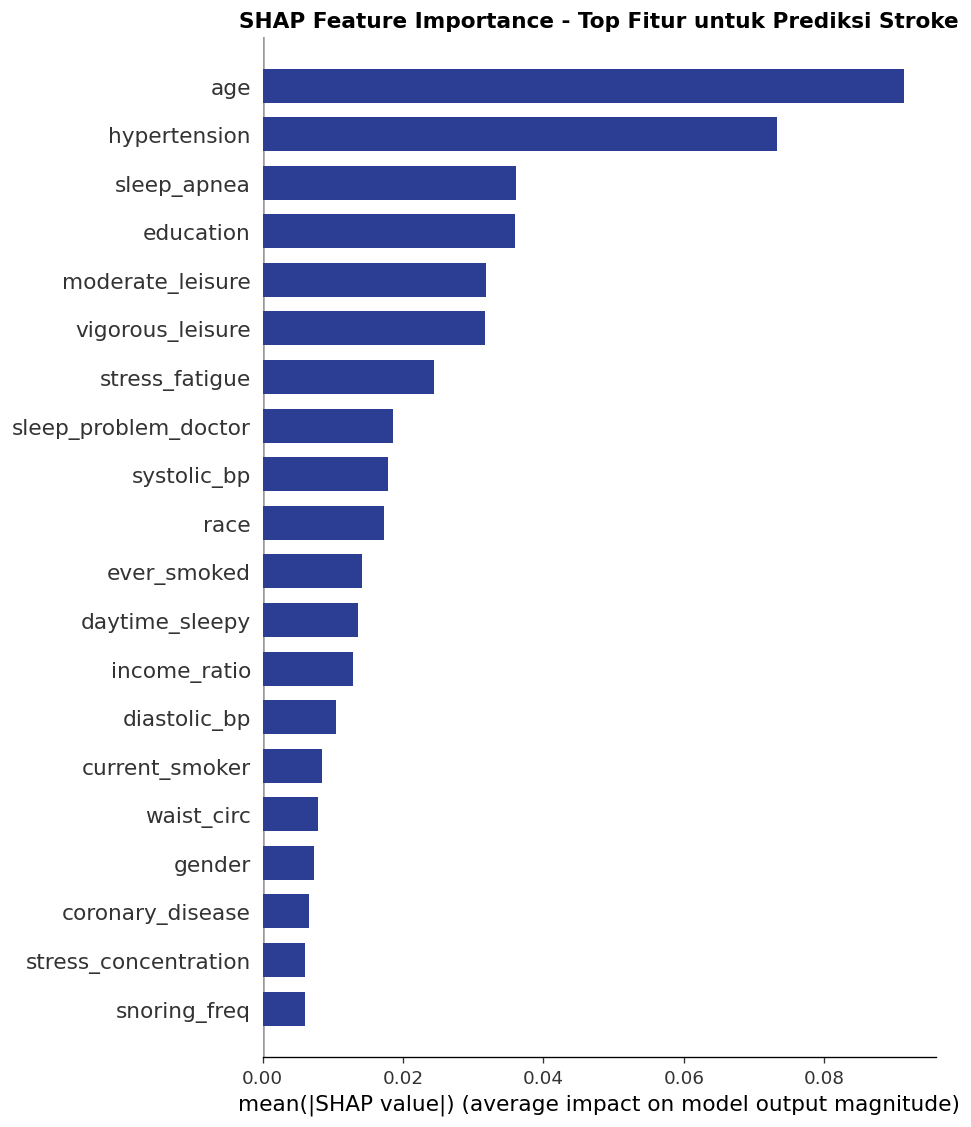

SHAP bar chart tersimpan di ../../reports/manual/figures/shap_summary_bar.png


In [12]:
plt.figure(figsize=(10, 8))
shap.summary_plot(sv_class1, X_sample_shap,
                  feature_names=best['features'],
                  plot_type='bar',
                  show=False,
                  color=COLORS[0])
plt.title('SHAP Feature Importance - Top Fitur untuk Prediksi Stroke',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/manual/figures/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP bar chart tersimpan di ../../reports/manual/figures/shap_summary_bar.png')

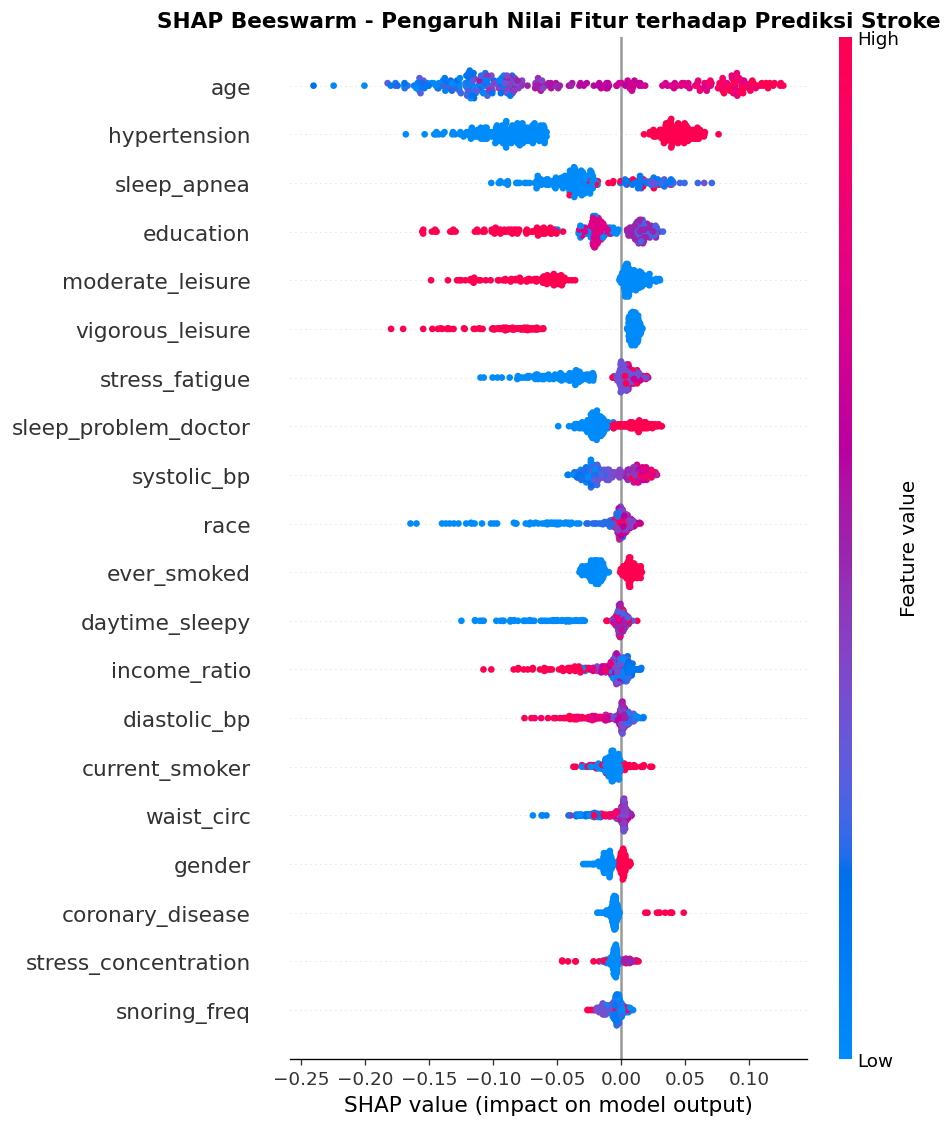

SHAP beeswarm plot tersimpan di ../../reports/manual/figures/shap_beeswarm.png


In [13]:
plt.figure(figsize=(10, 8))
shap.summary_plot(sv_class1, X_sample_shap,
                  feature_names=best['features'],
                  show=False)
plt.title('SHAP Beeswarm - Pengaruh Nilai Fitur terhadap Prediksi Stroke',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/manual/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP beeswarm plot tersimpan di ../../reports/manual/figures/shap_beeswarm.png')

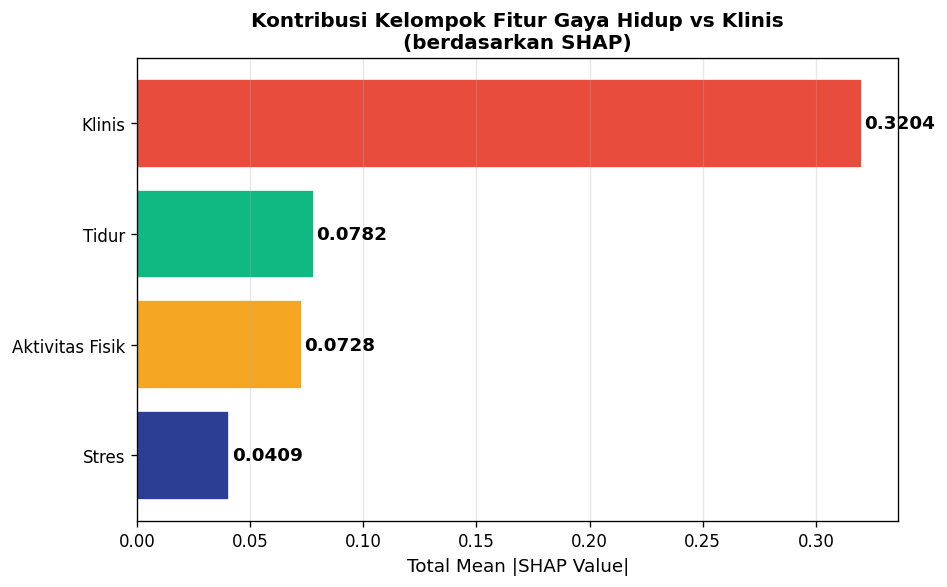


RANKING KELOMPOK FITUR (berdasarkan SHAP)
1. Klinis: 0.3204
2. Tidur: 0.0782
3. Aktivitas Fisik: 0.0728
4. Stres: 0.0409


In [14]:
available_feats = best['features']
shap_df = pd.DataFrame(np.abs(sv_class1), columns=available_feats)
mean_shap = shap_df.mean()

groups = {
    'Klinis': [c for c in CLINICAL if c in available_feats],
    'Tidur':  [c for c in SLEEP    if c in available_feats],
    'Stres':  [c for c in STRESS   if c in available_feats],
    'Aktivitas Fisik': [c for c in PHYSICAL if c in available_feats],
}

group_shap = {}
for grp, cols in groups.items():
    if cols:
        group_shap[grp] = mean_shap[cols].sum()

fig, ax = plt.subplots(figsize=(8, 5))
gs = pd.Series(group_shap).sort_values(ascending=True)
bars = ax.barh(gs.index, gs.values,
               color=[COLORS[0], COLORS[1], COLORS[2], COLORS[3]][:len(gs)],
               edgecolor='white')

for bar, val in zip(bars, gs.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Total Mean |SHAP Value|', fontsize=11)
ax.set_title('Kontribusi Kelompok Fitur Gaya Hidup vs Klinis\n(berdasarkan SHAP)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../../reports/manual/figures/shap_groups.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRANKING KELOMPOK FITUR (berdasarkan SHAP)')
for rank, (grp, val) in enumerate(gs.sort_values(ascending=False).items(), 1):
    print(f'{rank}. {grp}: {val:.4f}')

## 6. Export Hasil & Unduh

In [15]:
# Simpan tabel hasil ke CSV
results_df.to_csv('../../reports/manual/tables/hasil_eksperimen.csv', index=False)
print('hasil_eksperimen.csv tersimpan.')

# Download dari Colab
try:
    from google.colab import files
    files.download('../../reports/manual/tables/hasil_eksperimen.csv')
    files.download('../../reports/manual/figures/auc_comparison.png')
    files.download('../../reports/manual/figures/heatmap_auc.png')
    files.download('../../reports/manual/figures/roc_curve_scenario_E.png')
    files.download('../../reports/manual/figures/shap_summary_bar.png')
    files.download('../../reports/manual/figures/shap_beeswarm.png')
    files.download('../../reports/manual/figures/shap_groups.png')
    print('Semua file berhasil didownload!')
except Exception as e:
    print('(Tidak di Colab - file gambar dan CSV tersimpan di direktori lokal)')

hasil_eksperimen.csv tersimpan.
(Tidak di Colab - file gambar dan CSV tersimpan di direktori lokal)
